# 4.2 The Formation of Molecular Oxygen

<!-- One H1 per notebook ("# <number> <Title>"): it sets the sidebar entry,
     breadcrumb, browser tab, and search result. The branded banner below is
     generated by the shared `ecp` package. -->

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume IV — Electronic Structure",
    number="4.2",
    title="The Formation of Molecular Oxygen",
    blurb="Why oxygen is magnetic, read from a real CP2K calculation: the electron "
    "density and the charge that builds up on bonding, the molecular orbitals "
    "themselves, and the spin-split eigenvalues that put two unpaired electrons "
    "in the π* orbitals and make O₂ a triplet.",
    difficulty="intermediate",
    estimate="90–120 min",
    source="FS 2023 · Lecture 6 (molecular orbital theory)",
)

<ECP header: 2847 chars of HTML>

## Notebook overview

This exercise examines the formation of **triplet oxygen**, the most stable and
most common form of O₂. Triplet oxygen has two electrons in its two **degenerate**
$\pi^*$ orbitals, and according to **Hund's rules** the configuration with those
two electrons unpaired, with parallel spins, is the one nature chooses: the total
spin is $S=1$, a triplet, and the molecule is magnetic. A simple Lewis structure,
with every electron paired, misses this entirely. Molecular-orbital theory does
not, and it is the molecular-orbital picture we build and verify here.

We work from a real density-functional calculation. The course ran O₂ in **CP2K**,
printing the electron density and the frontier molecular orbitals to cube files,
and we use that genuine output: we visualise the electron density, compute the
**density difference** that shows where charge moves when the bond forms, look at
the **molecular orbitals** one by one, repeat for the single oxygen **atom**, and
finally read the **spin-split eigenvalues** from the run to build the
molecular-orbital schema and explain the paramagnetism.

> **Provenance.** This notebook develops **Lecture 6** of the course (the formation
> of molecular oxygen via molecular-orbital theory), an exercise **designed by the
> author (Raymond Amador)**, and follows its assignments.
> The cube visualisations and eigenvalues are the *real* CP2K output of the
> exercise (an anonymised course run), with the volumetric cubes downsampled for
> size; the input deck shown is the course's own. The full course credit is in the
> footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: electron conservation, the electron count of the molecule versus the atom,
> the spin imbalance that defines the triplet. A ✗ flags a mismatch to track down,
> not a verdict; a ✓ is strong evidence, not proof.

> **Scope.** Cube data are visualised as isosurfaces; energies are converted from
> Hartree to eV. For the chemistry see Atkins & Friedman {cite}`atkins-mqm`; the
> calculations were run in CP2K, the cube format stores a scalar field on a 3-D
> grid.

## Theory in brief

### From atomic orbitals to molecular orbitals

When two atoms bond, their atomic orbitals combine into **molecular orbitals**: an
in-phase **bonding** combination, lower in energy, with charge piled up between the
nuclei, and an out-of-phase **antibonding** combination (starred), higher in
energy, with a node between them. For O₂ the valence $2s$ and $2p$ orbitals build
the set

```{math}
:label: eq-mo-set
\sigma_{2s},\ \sigma_{2s}^{*},\ \sigma_{2p},\ \pi_{2p}{=}\pi_{2p},\ \pi_{2p}^{*}{=}\pi_{2p}^{*},\ \sigma_{2p}^{*},
```

the two $\pi_{2p}$ and the two $\pi_{2p}^{*}$ each a degenerate pair. Oxygen brings
six valence electrons each, twelve in all, which fill the diagram from the bottom
and leave the last **two electrons in the degenerate $\pi^*$ pair**.

### Spin, and the triplet

Two electrons in two equal orbitals follow **Hund's rule**: one in each, spins
parallel, because same-spin electrons keep apart (Pauli) and so repel less. The
spins do not cancel ($S=1$), the molecule is a **triplet**, and it is
**paramagnetic**, with a spin-only moment $\mu=\sqrt{n(n+2)}\,\mu_B$ for $n$
unpaired electrons. A spin-polarised calculation makes this concrete by solving for
spin-up ($\alpha$) and spin-down ($\beta$) electrons separately: the two unpaired
$\pi^*$ electrons are both $\alpha$, so the molecule has **two more $\alpha$
electrons than $\beta$**, the numerical fingerprint of the triplet that we will
read straight off the eigenvalues.

### What the calculation gives us

Density-functional theory in CP2K returns the electron density $\rho(\mathbf r)$,
the individual Kohn-Sham (molecular) orbitals $\psi_i(\mathbf r)$, and their
energies $\varepsilon_i$, written to **cube files** (a scalar on a 3-D grid) and to
the output log. Subtracting the densities of the separated atoms from the molecule
gives the **density difference**, a direct picture of the bond; the orbital cubes
show the $\sigma$ and $\pi$ shapes themselves; and the eigenvalues, split by spin,
build the molecular-orbital schema.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_EV = 27.211386
BOHR_A = 0.529177


def data_file(name):
    """Locate a shipped data file, from the repo root (CI) or the notebook dir (Colab).

    Parameters
    ----------
    name : str
        File name (or relative path) under a ``data`` directory.

    Returns
    -------
    str
        The first existing path found.

    Raises
    ------
    FileNotFoundError
        If the file is not found under any candidate base.
    """
    for base in ("data", os.path.join("notebooks", "04-electronic-structure", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_cube(name):
    """Parse a Gaussian cube file.

    Parameters
    ----------
    name : str
        Cube file name.

    Returns
    -------
    dict
        Keys: ``label``, ``origin`` (3,), ``vec`` (3, 3) voxel vectors, ``atoms``
        (n_at, 3) coordinates, ``data`` the 3-D scalar grid, and ``dV`` the
        voxel volume.
    """
    lines = open(data_file(name)).read().splitlines()
    label = lines[0].strip()
    n_at = int(lines[2].split()[0])
    origin = np.array(lines[2].split()[1:4], float)
    vec = np.array([[float(x) for x in lines[3 + i].split()[1:4]] for i in range(3)])
    ng = [int(lines[3 + i].split()[0]) for i in range(3)]
    atoms = np.array([[float(x) for x in lines[6 + i].split()[2:5]] for i in range(n_at)])
    data = np.array(" ".join(lines[6 + n_at:]).split(), float).reshape(ng)
    return dict(label=label, origin=origin, vec=vec, atoms=atoms, data=data,
                dV=abs(np.linalg.det(vec)))


def show_isosurface(cube, levels, title):
    """Render cube isosurfaces with the atoms marked, on a new 3-D figure.

    Parameters
    ----------
    cube : dict
        A parsed cube from ``read_cube``.
    levels : list of tuple
        ``(isovalue, colour)`` pairs (amber for positive lobes, navy for negative).
    title : str
        Figure title.

    Returns
    -------
    matplotlib.figure.Figure
        The figure with the rendered isosurface(s).
    """
    d, vec, origin = cube["data"], cube["vec"], cube["origin"]
    spacing = (vec[0, 0], vec[1, 1], vec[2, 2])
    fig = plt.figure(figsize=(4.6, 4.4))
    ax = fig.add_subplot(projection="3d")
    for lvl, col in levels:
        if d.min() < lvl < d.max():
            verts, faces, _, _ = marching_cubes(d, level=lvl, spacing=spacing)
            verts = verts + origin
            ax.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                            color=col, alpha=0.45, lw=0)
    ax.scatter(cube["atoms"][:, 0], cube["atoms"][:, 1], cube["atoms"][:, 2],
               s=140, color="#444", depthshade=False)
    ax.set(xticks=[], yticks=[], zticks=[], title=title)
    ax.set_box_aspect((1, 1, 1))
    return fig

## Exercise 1 — The CP2K input file

Every calculation starts from its input deck. The course's `triplet.inp` is a
spin-polarised (`LSD`) Hartree-Fock run with the **triplet** imposed through
`MULTIPLICITY 3` (so $2S+1=3$, $S=1$), and a `&PRINT` block that writes the cube
files we will use:

```text
&DFT
  LSD                       ! spin-polarised: separate alpha and beta densities
  MULTIPLICITY 3            ! triplet (two unpaired electrons)
  &PRINT
    &E_DENSITY_CUBE         ! write the electron density to a cube file
    &END E_DENSITY_CUBE
    &MO_CUBES               ! write molecular-orbital cubes
      NHOMO 1               ! ... the HOMO (and neighbours)
      NLUMO 1               ! ... and the LUMO
    &END MO_CUBES
  &END PRINT
&END DFT
```

It ships with this notebook: {download}`triplet.inp <data/o2-triplet.inp>`. Those
two print directives are exactly what generate the density and orbital cubes the
rest of the exercise visualises.

**Part a)** Read the deck. **Part b)** Confirm it requests a triplet and the cube
output.

In [3]:
# (solution hidden on the public site)


MULTIPLICITY = 3  ->  S = 1 (triplet); writes density cube: True


### Validation 1 — the deck describes a triplet with cube output

The input must specify multiplicity 3 (a spin-1 triplet) and request the electron
density cube, the two ingredients the rest of the exercise depends on.

In [4]:
validate.check(
    multiplicity == 3 and spin_S == 1 and writes_density,
    "the input deck requests a triplet (multiplicity 3) and writes the density cube",
    f"MULTIPLICITY = {multiplicity} (S = {spin_S:.0f}), E_DENSITY_CUBE = {writes_density}",
)

✓  the input deck requests a triplet (multiplicity 3) and writes the density cube   [MULTIPLICITY = 3 (S = 1), E_DENSITY_CUBE = True]


True

## Exercise 2 — The electron density

Once the job finishes it writes the electron density to a cube file: the scalar
$\rho(\mathbf r)$ on a 3-D grid. We render it as an **isosurface**, the surface on
which the density takes a chosen value, with the two oxygen nuclei marked. The
density is a single smooth cloud enveloping both atoms, the hallmark of a bound
molecule rather than two separate ones.

**Part a)** Read and render the O₂ electron-density cube. **Part b)** Confirm it is
a physical density.

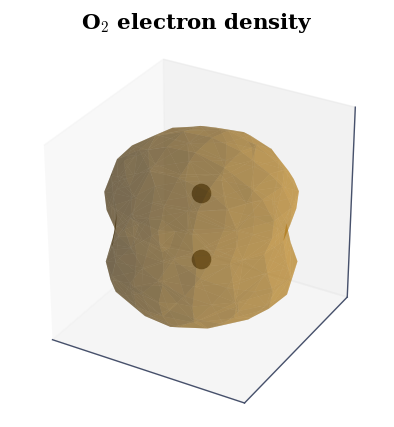

In [5]:
# (solution hidden on the public site)


### Validation 2 — a physical electron density

A real electron density is non-negative everywhere. (The integral under-counts
here only because the cube was downsampled for size, blurring the sharp peaks at
the nuclei; we check the electron *count* properly in Exercises 3 and 5.)

In [6]:
validate.check(
    o2_density["data"].min() > -1e-4,
    "the electron density is non-negative everywhere (to numerical noise)",
    f"min ρ = {o2_density['data'].min():.2e}, max ρ = {o2_density['data'].max():.3f}",
)

✓  the electron density is non-negative everywhere (to numerical noise)   [min ρ = -8.76e-06, max ρ = 0.946]


True

## Exercise 3 — The density difference (Assignment 1)

The total density is striking but not the most informative quantity; the
*difference* is. Subtracting the densities of the two separate oxygen atoms from
the molecule's density, $\Delta\rho=\rho_{\mathrm{O_2}}-\rho_{\mathrm{O}}-\rho_{\mathrm{O}}$,
isolates exactly the charge that **rearranges when the bond forms**: amber where
electrons accumulate, navy where they are depleted. Because the molecule and the
two atoms hold the same total number of electrons, the difference must integrate to
zero, which is our check.

**Part a)** Render the density-difference cube. **Part b)** Confirm electron number
is conserved.

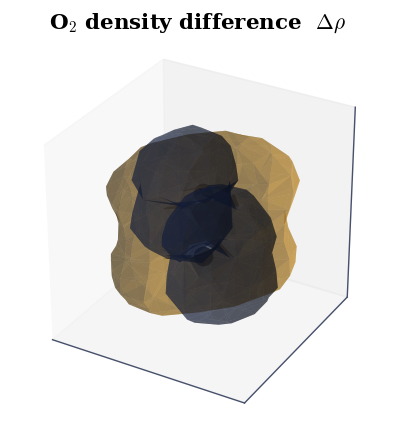

In [7]:
# (solution hidden on the public site)


### Validation 3 — electron conservation

Forming a bond moves charge around but neither creates nor destroys it, so the
density difference must integrate to ≈ 0.

In [8]:
validate.close(delta_n, 0.0, "the density difference integrates to zero (electrons conserved)", atol=0.05)

✓  the density difference integrates to zero (electrons conserved)   [got -0.0194206 vs expected 0 (rtol=1e-06)]


True

## Exercise 4 — The molecular orbitals (Assignment 2)

The calculation also prints individual **molecular orbitals**. Their cube file
names encode which orbital each is: a comment line reads `WAVEFUNCTION i spin s
i.e. HOMO - n`, so the highest occupied (the HOMO) is $n=0$, the one below it
$n=1$, and so on. Decoding those tags identifies three valence orbitals worth
seeing: a bonding $\pi_{2p}$, a bonding $\sigma_{2p}$, and the **antibonding
$\pi^*$** that is the HOMO and holds the two unpaired electrons. Bonding orbitals
concentrate charge between the nuclei; the antibonding $\pi^*$ has a node there,
visible as the change of lobe colour across the bond.

**Part a)** Render the three orbitals. **Part b)** Confirm they are proper
(normalised) one-electron orbitals.

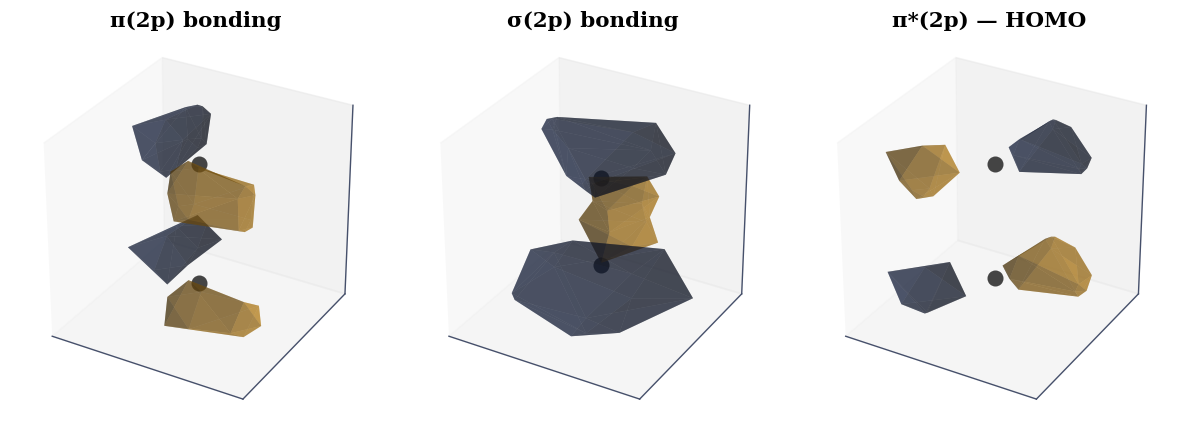

In [9]:
# (solution hidden on the public site)


### Validation 4 — proper one-electron orbitals

Each Kohn-Sham orbital is normalised, so $\int|\psi|^2\,dV$ must be the same for all
three (the same value the downsampling preserves), confirming they are genuine
single-electron molecular orbitals.

In [10]:
validate.close(np.array(norms), norms[0], "the three orbitals share one normalisation (∫|ψ|² equal)", rtol=0.05)

✓  the three orbitals share one normalisation (∫|ψ|² equal)   [max|Δ| = 0.0329698 (rtol=0.05, atol=1e-09)]


True

## Exercise 5 — The oxygen atom (Assignment 3)

The same calculation for a single oxygen atom gives a reference. Its density is one
spherical-ish cloud about a single nucleus, and crucially it holds **half** the
electrons of the molecule. Comparing the integrated densities is a clean,
downsampling-proof check: the molecule must contain exactly twice the atom's
electrons (16 versus 8), so the *ratio* of the integrals is 2 even though each
absolute integral is undercounted by the coarse grid.

**Part a)** Render the O-atom density. **Part b)** Confirm the molecule has twice
the atom's electrons.

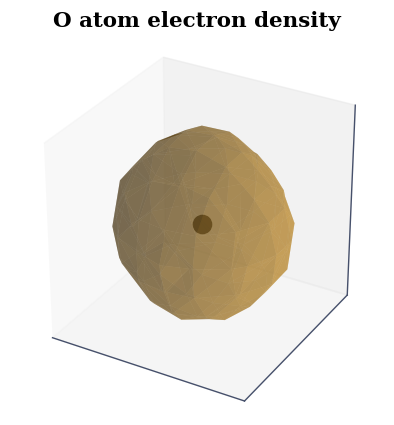

∫ρ(O₂) / ∫ρ(O) = 1.998  (O₂ has 16 electrons, O has 8  ->  ratio 2)


In [11]:
# (solution hidden on the public site)


### Validation 5 — the molecule has twice the atom's electrons

The ratio of the integrated densities must be 2: the molecule is two oxygen atoms'
worth of electrons.

In [12]:
validate.close(ratio, 2.0, "O₂ holds twice the electrons of an O atom (integral ratio = 2)", rtol=0.03)

✓  O₂ holds twice the electrons of an O atom (integral ratio = 2)   [got 1.99767 vs expected 2 (rtol=0.03)]


True

## Exercise 6 — The eigenvalues and the molecular-orbital schema (Assignment 4)

Finally we read the energies. The output lists the occupied eigenvalues separately
for spin-up ($\alpha$) and spin-down ($\beta$), and the asymmetry is the whole
story: there are **nine occupied $\alpha$ orbitals but only seven occupied
$\beta$**, a difference of two. Those two extra spin-up electrons sit in the
degenerate $\pi^*$ pair with no spin-down partners, exactly the unpaired electrons
of the triplet. Dropping the two core $1s$ states, we plot the valence levels at
their real energies and fill them with $\alpha$ (up) and $\beta$ (down) electrons,
reproducing the molecular-orbital schema from the calculation itself.

**Part a)** Build the schema from the real eigenvalues. **Part b)** Confirm the
spin imbalance, and the paramagnetic moment it implies.

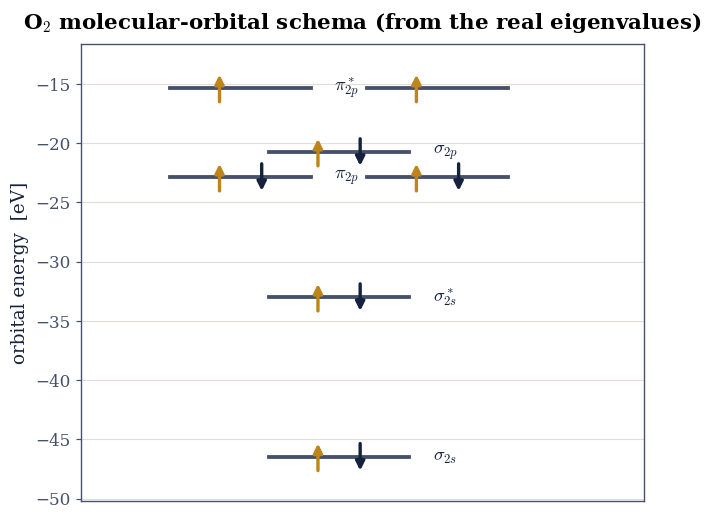

occupied: 9 α, 7 β  ->  2 unpaired electrons; μ = 2.83 μ_B


In [13]:
# (solution hidden on the public site)


### Validation 6 — two unpaired electrons, a paramagnetic triplet

The spin-up/spin-down imbalance must be exactly two unpaired electrons, giving spin
$S=1$ and the spin-only moment $\mu=\sqrt{8}\approx2.83\,\mu_B$: O₂ is a
paramagnetic triplet, the result a Lewis structure cannot give.

In [14]:
validate.check(
    n_unpaired == 2 and abs(mu - np.sqrt(8)) < 1e-6,
    "O₂ has two unpaired electrons (S=1) and a non-zero magnetic moment",
    f"{n_unpaired} unpaired → μ = {mu:.2f} μ_B",
)

✓  O₂ has two unpaired electrons (S=1) and a non-zero magnetic moment   [2 unpaired → μ = 2.83 μ_B]


True

## Notebook summary

We worked the real CP2K calculation of molecular oxygen end to end: the electron
density, the bonding charge build-up in the density difference (which integrates to
zero, conserving electrons), the bonding $\pi$ and $\sigma$ and antibonding $\pi^*$
molecular orbitals, and the single oxygen atom for comparison. The spin-resolved
eigenvalues told the central story: nine occupied $\alpha$ orbitals against seven
$\beta$, the difference of two being the unpaired electrons in the degenerate
$\pi^*$ pair. That is why ground-state O$_2$ is a paramagnetic triplet, the result
a Lewis structure cannot give.

## Outlook

- **The spin density.** The calculation also wrote a spin-density cube,
  $\rho_\alpha-\rho_\beta$; rendering it shows the unpaired-electron density sitting
  exactly in the $\pi^*$ orbitals.
- **Singlet oxygen.** Pairing the two $\pi^*$ electrons gives the reactive ¹Δg
  state, 0.98 eV higher; it is multireference, so a single-determinant method
  describes it only crudely.
- **The second row.** B₂ is paramagnetic for the same reason, while C₂ and N₂ are
  not; the $\sigma_{2p}/\pi_{2p}$ ordering switches before O₂ through s–p mixing.
- **Beyond Hartree-Fock.** O₂'s bond energy needs correlated methods (CCSD(T)) or
  good functionals; Hartree-Fock alone underbinds it badly.

### References

```{bibliography}
:filter: docname in docnames
```

In [15]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>